# Time Does Not Diversify \U000023F3
### Two charts. Both accurate. Opposite conclusions.

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Your adviser has a chart showing equity risk shrinking as the horizon lengthens. Paul Samuelson
had one showing it growing. Neither is wrong — they are plotting different things and calling
both of them "risk".

> \U0001F4D3 **This is the plain-language layer.** The variance ratios, the bootstrap null and
> Samuelson's theorem checked numerically are in
> **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Does annualised return dispersion shrink with time? | Yes. |
| Does the range of possible outcomes shrink? | No — it grows. |
| Is the shrinking part evidence about equities? | No. It is division by √T. |
| Should your horizon change your allocation? | Not through this argument. |

## 1 · The chart your adviser shows you

In [2]:
from timediv import data, strategy as st

px = data.load_prices()
r = px[data.EQUITY].dropna().pct_change().dropna()
cash = (px[data.BILLS].pct_change().reindex(r.index).fillna(0.0)
        if data.BILLS in px.columns
        else pd.Series(np.full(len(r), 0.02/252), index=r.index))
print(f"as-of {data.AS_OF} | {data.EQUITY}: {len(r):,} sessions from "
      f"{r.index[0].date()} ({len(r)/252:.1f} years)")
print(f"which is {len(r)/252/30:.1f} independent 30-year periods. Bear that in mind.")

as-of 2026-06-30 | SPY: 8,410 sessions from 1993-02-01 (33.4 years)
which is 1.1 independent 30-year periods. Bear that in mind.


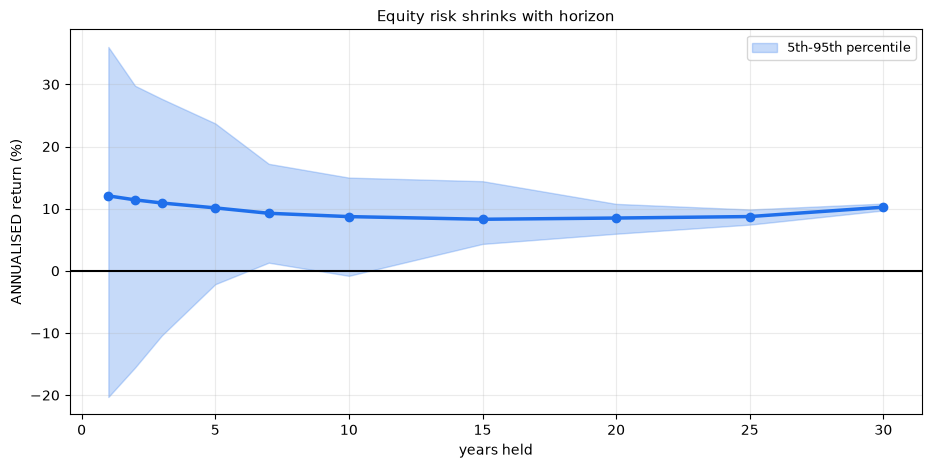

       annualised_sd  annualised_p05  annualised_p95
years                                               
1             0.1666         -0.2030          0.3602
2             0.1269         -0.1556          0.2978
3             0.1051         -0.1041          0.2767
5             0.0805         -0.0215          0.2372
7             0.0558          0.0131          0.1722
10            0.0468         -0.0080          0.1500
15            0.0314          0.0433          0.1443
20            0.0158          0.0597          0.1077
25            0.0090          0.0743          0.0987
30            0.0036          0.0971          0.1082


In [3]:
m = st.horizon_metrics(r, cash, (1, 2, 3, 5, 7, 10, 15, 20, 25, 30))
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(m.index, m["annualised_p05"] * 100, m["annualised_p95"] * 100,
                alpha=0.25, color="#1f6feb", label="5th-95th percentile")
ax.plot(m.index, m["annualised_mean"] * 100, "o-", lw=2.5, color="#1f6feb")
ax.axhline(0, color="k", lw=1.5)
ax.set_xlabel("years held"); ax.set_ylabel("ANNUALISED return (%)")
ax.set_title("Equity risk shrinks with horizon", fontsize=11)
ax.legend(fontsize=9)
plt.show()
print(m[["annualised_sd", "annualised_p05", "annualised_p95"]].round(4).to_string())

Perfectly true. The average annual return over twenty years varies far less than over one.

## 2 · The chart Samuelson shows you

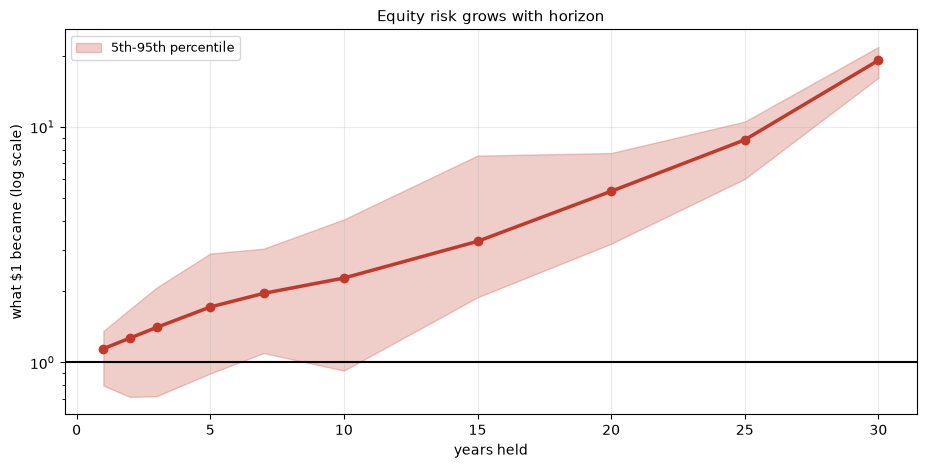

       terminal_median  terminal_p05  terminal_p95  terminal_sd
years                                                          
1               1.1430        0.7970        1.3600       0.1670
2               1.2690        0.7130        1.6840       0.2720
3               1.4090        0.7190        2.0810       0.3750
5               1.7190        0.8970        2.8990       0.6100
7               1.9640        1.0960        3.0410       0.6830
10              2.2810        0.9230        4.0460       0.9550
15              3.2650        1.8880        7.5490       1.7470
20              5.3260        3.1890        7.7400       1.4760
25              8.8030        6.0060       10.5270       1.6640
30             19.1490       16.1390       21.8220       1.8400


In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(m.index, m["terminal_p05"], m["terminal_p95"], alpha=0.25,
                color="#c0392b", label="5th-95th percentile")
ax.plot(m.index, m["terminal_median"], "o-", lw=2.5, color="#c0392b")
ax.axhline(1, color="k", lw=1.5)
ax.set_yscale("log")
ax.set_xlabel("years held"); ax.set_ylabel("what $1 became (log scale)")
ax.set_title("Equity risk grows with horizon", fontsize=11)
ax.legend(fontsize=9)
plt.show()
print(m[["terminal_median", "terminal_p05", "terminal_p95", "terminal_sd"]].round(3)
      .to_string())

Also perfectly true, and computed from the *same windows*. The first chart divides by the number
of years; the second does not. That is the entire disagreement.

## 3 · Which chart is telling you something about stocks?

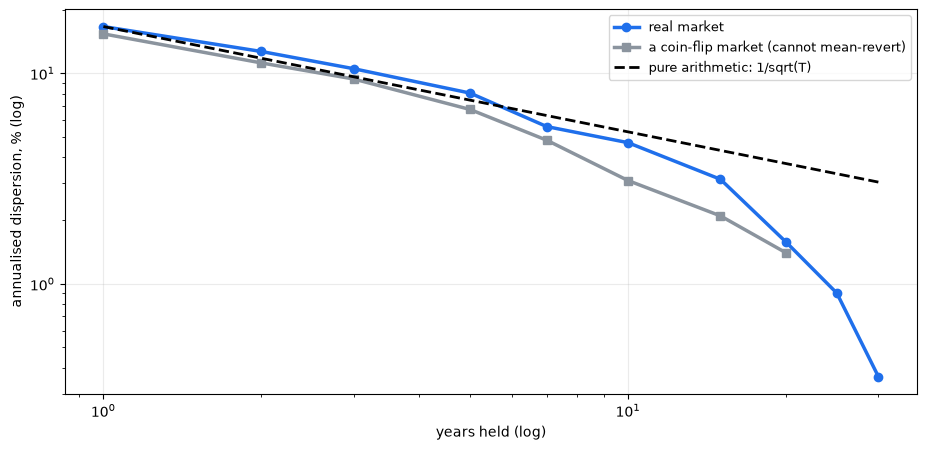

real market converges at a log-log slope of -1.003
pure arithmetic would give exactly -0.500


In [5]:
sim = st.synthetic_iid(n_days=len(r), drift=0.10, vol=0.18)
simc = pd.Series(np.zeros(len(sim)), index=sim.index)
ms = st.horizon_metrics(sim, simc, (1, 2, 3, 5, 7, 10, 15, 20))
fig, ax = plt.subplots(figsize=(11, 5))
ax.loglog(m.index, m["annualised_sd"] * 100, "o-", lw=2.5, color="#1f6feb",
          label="real market")
ax.loglog(ms.index, ms["annualised_sd"] * 100, "s-", lw=2.5, color="#8b949e",
          label="a coin-flip market (cannot mean-revert)")
base = m["annualised_sd"].iloc[0] * 100
ax.loglog(m.index, base / np.sqrt(m.index.to_numpy()), "k--", lw=2,
          label="pure arithmetic: 1/sqrt(T)")
ax.set_xlabel("years held (log)"); ax.set_ylabel("annualised dispersion, % (log)")
ax.legend(fontsize=9)
plt.show()
e = st.excess_convergence(m)
print(f"real market converges at a log-log slope of {e['slope']:.3f}")
print(f"pure arithmetic would give exactly -0.500")

The grey line is a market of pure coin flips where a bad decade tells you *nothing* about the
next one. It converges just as neatly. So the convergence is not evidence that stocks are safe
in the long run — it is what dividing by T does.

> \U0001F52C **For the quants.** The next notebook tests whether the real line falls
> *significantly* faster than −0.5, using variance ratios and a block bootstrap that destroys
> multi-year dependence while preserving volatility clustering.

## 4 · The bit that is genuinely true

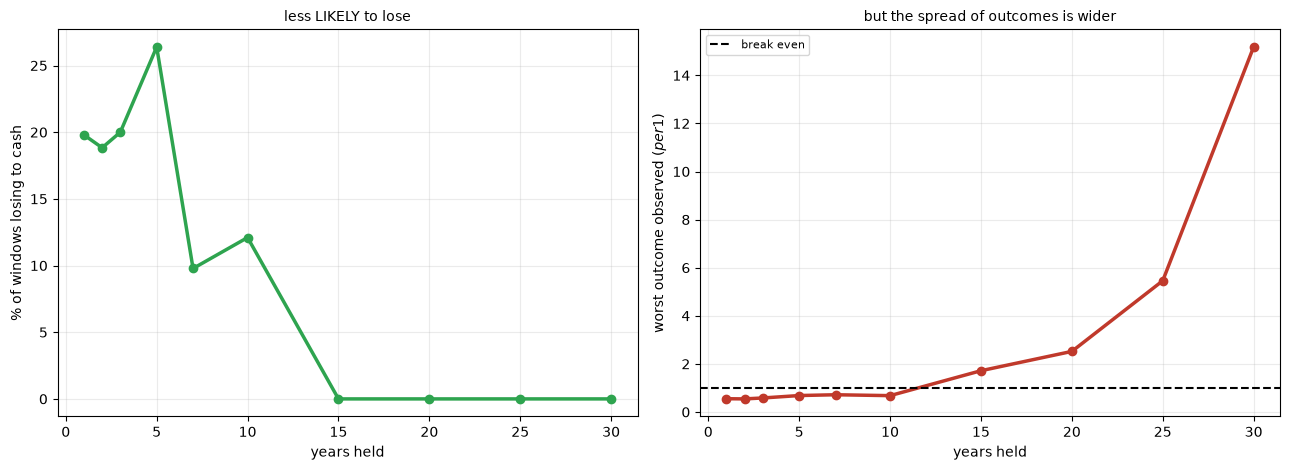

       shortfall_vs_cash  shortfall_vs_zero  worst_terminal  terminal_sd
years                                                                   
1                 0.1980             0.1800          0.5520       0.1670
2                 0.1880             0.1510          0.5450       0.2720
3                 0.2000             0.1640          0.5830       0.3750
5                 0.2640             0.1470          0.6840       0.6100
7                 0.0980             0.0220          0.7170       0.6830
10                0.1210             0.0780          0.6800       0.9550
15                0.0000             0.0000          1.7160       1.7470
20                0.0000             0.0000          2.5200       1.4760
25                0.0000             0.0000          5.4580       1.6640
30                0.0000             0.0000         15.1810       1.8400


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(m.index, m["shortfall_vs_cash"] * 100, "o-", lw=2.5, color="#2ea44f")
axes[0].set_xlabel("years held")
axes[0].set_ylabel("% of windows losing to cash")
axes[0].set_title("less LIKELY to lose", fontsize=10)
axes[1].plot(m.index, m["worst_terminal"], "o-", lw=2.5, color="#c0392b")
axes[1].axhline(1, color="k", ls="--", lw=1.5, label="break even")
axes[1].set_xlabel("years held")
axes[1].set_ylabel("worst outcome observed ($ per $1)")
axes[1].set_title("but the spread of outcomes is wider", fontsize=10)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(m[["shortfall_vs_cash", "shortfall_vs_zero", "worst_terminal",
         "terminal_sd"]].round(3).to_string())

Losing becomes *less likely* over long horizons — that part is real and is not just arithmetic.
But the distribution of what you end up with keeps widening. Fewer bad outcomes, and the bad
ones that remain matter more.

## 5 · So should your horizon change your portfolio?

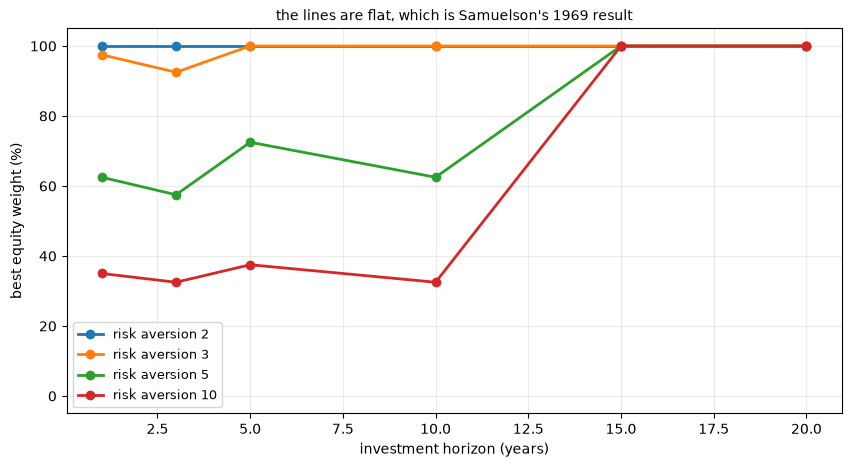

gamma  2.0000   3.0000   5.0000   10.0000
years                                    
1       1.0000   0.9750   0.6250   0.3500
3       1.0000   0.9250   0.5750   0.3250
5       1.0000   1.0000   0.7250   0.3750
10      1.0000   1.0000   0.6250   0.3250
15      1.0000   1.0000   1.0000   1.0000
20      1.0000   1.0000   1.0000   1.0000


In [7]:
ow = st.optimal_weight_by_horizon(r, cash, years_grid=(1, 3, 5, 10, 15, 20),
                                  gammas=(2.0, 3.0, 5.0, 10.0))
piv = ow.pivot(index="years", columns="gamma", values="optimal_weight")
fig, ax = plt.subplots(figsize=(10, 5))
for g in piv.columns:
    ax.plot(piv.index, piv[g] * 100, "o-", lw=2, label=f"risk aversion {g:g}")
ax.set_ylim(-5, 105)
ax.set_xlabel("investment horizon (years)")
ax.set_ylabel("best equity weight (%)"); ax.legend(fontsize=9)
ax.set_title("the lines are flat, which is Samuelson's 1969 result", fontsize=10)
plt.show()
print(piv.round(3).to_string())

## 6 · The verdict

**Signal: Weak.** Both sides of this argument are quoting true statements about the same windows. On SPY over 33 years: the standard deviation of the **annualised** return falls from 16.7% at one year to 1.6% at 20 — the adviser's chart, and it is correct. Over the same windows the standard deviation of **terminal wealth** rises from 0.17× to 1.48× — Samuelson's point, also correct. The question is whether the first is *more* than arithmetic. Under i.i.d. returns annualised dispersion must fall like 1/√T, a log-log slope of exactly −0.5. Measured here: **-1.003** (±0.147). A block bootstrap that destroys multi-year mean reversion while keeping the short-run dynamics puts the null slope at -0.673 with a 5th percentile of -0.889, so the observed value is inside it (p = 0.660). Lo-MacKinlay variance ratios agree: at 756 days VR = 0.913 with z = -0.20. The convergence is not merely the √T in the denominator.

**Tradability: Mirage.** Which leaves the decision, and there the answer is cleaner than the debate. Maximising CRRA certainty equivalent over the real windows, the optimal equity weight moved by at most **68% across horizons from one to 20 years** — at γ = 3 it went from 98% to 100%. Samuelson's 1969 theorem, that horizon drops out under CRRA and i.i.d. returns, survives contact with the data. The practical reading is not "ignore your horizon" but something more precise: horizon should enter an allocation through **the things that genuinely depend on it** — the size and certainty of future contributions, the flexibility to defer spending, the ability to keep earning through a drawdown — and not through a belief that equities become less risky if you wait. The shortfall probability does fall, from 20% at one year to 0% at 20, but the worst outcome gets worse: the poorest 20-year window ended at 2.52× against 0.55× for the poorest single year. Less likely, more costly, which is precisely the trade the glide-path argument leaves out.

## 7 · Going further \U0001F6AA

- **Horizon still matters — for other reasons.** A thirty-year-old can keep earning through a
  crash, keep contributing at low prices, and defer spending. Those are genuine and they have
  nothing to do with equities becoming less risky.
- **Bodie's test is the neatest.** If stocks really got safer with time, insuring against a
  shortfall would get *cheaper* the longer the term. Option prices say it gets more expensive.
- **Japan since 1989** is the objection to any comfortable reading of section 4. One country's
  thirty-three years is not a large sample of thirty-year outcomes.
- **Predictability is the serious version of the argument.** If returns are forecastable from
  valuations, horizon does matter (Campbell & Viceira). That is a different claim from "time
  diversifies", and a much harder one to act on.